<a href="https://colab.research.google.com/github/sathasivamn/Self-Project-1---Gold-Prediction/blob/main/Project_Gold_Price_Prediction_Random_Forest_Regression_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gold Price Prediction - Random Forest Regression Model

# 1: Import Libraries

In [2]:
# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Explanation:
## pandas and numpy for data manipulation,
## matplotlib and seaborn for data visualization,
## sklearn modules for model building and evaluation.

# 2: Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('gold_data.csv')

# Display first few rows
df.head()

,Date,Price,Open,High,Low,Volume
0,29/09/2015,1127.1,1132.4,1133.6,1123.9,0.25
1,30/09/2015,1115.5,1127.5,1127.5,1111.3,0.28
2,01/10/2015,1114.0,1114.9,1118.3,1111.0,0.26
3,02/10/2015,1136.7,1113.0,1140.7,1105.0,0.47
4,05/10/2015,1137.7,1138.7,1141.3,1129.8,0.20


# 3: Explore and Preprocess the Data

In [4]:
# Check for null values
print(df.isnull().sum())

# Basic statistics
df.describe()

Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
dtype: int64


,Price,Open,High,Low,Volume
count,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000
mean,1480.877644,1478.720355,1487.743110,1469.452300,93.260327
std,276.132747,273.356556,275.498167,270.560201,137.485763
min,1049.700000,1051.100000,1062.700000,1045.700000,0.000000
25%,1257.225000,1257.675000,1264.975000,1251.675000,0.580000
50%,1334.600000,1334.700000,1341.750000,1326.850000,1.895000
75%,1787.750000,1783.250000,1791.050000,1774.425000,205.345000
max,2054.600000,2062.400000,2085.200000,2033.600000,816.530000


# Explanation:
## We check for missing values and basic statistics to understand data distribution.

#4: Data Correlation and Feature Selection

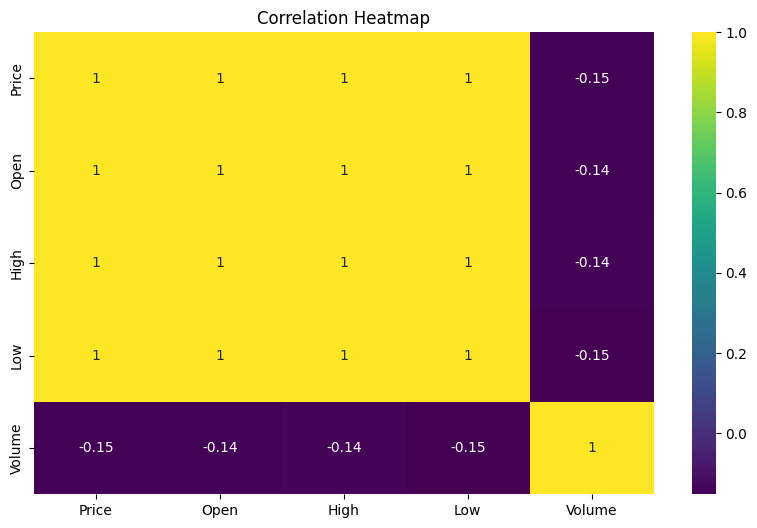

In [8]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')  # Assuming 'dd/mm/yyyy' format

# Extract numerical features for correlation analysis
numerical_features = df.select_dtypes(include=['number'])

# Visualize correlation matrix for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_features.corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

# Explanation:
## We generate a correlation heatmap to understand which features are most related to the gold price.

# 5: Define Features (X) and Target (y)

In [16]:
# Assume the target is 'GLD' (Gold Price) — update if different
X = df.drop(['Price', 'Date'], axis=1)  # Dropping 'Date' column
y = df['Price']  # Changed 'GLD' to 'Price'

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Explanation:
## We separate features and target variable, then split the data into training and testing sets.

# 6: Train the Random Forest Regressor

In [17]:
# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Explanation:
## We initialize the Random Forest Regressor with 100 trees and train it using the training data.

# 7: Evaluate the Model

In [18]:
# Predict on test data
y_pred = model.predict(X_test)

In [19]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [20]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 98.88
R² Score: 1.00


# Explanation:
## We use metrics like Mean Squared Error and R² Score to evaluate model performance.

# 8: Predict Future Prices (Example Input)

In [21]:
# Example: Predict gold price for the first row of test set
example = X_test.iloc[0].values.reshape(1, -1)
predicted_price = model.predict(example)
print(f"Predicted Gold Price: {predicted_price[0]:.2f}")

Predicted Gold Price: 1823.58


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#  Explanation:
## We predict the gold price using a sample from the test data as a simulation of future prediction.